##**Feature Correlation Analysis**

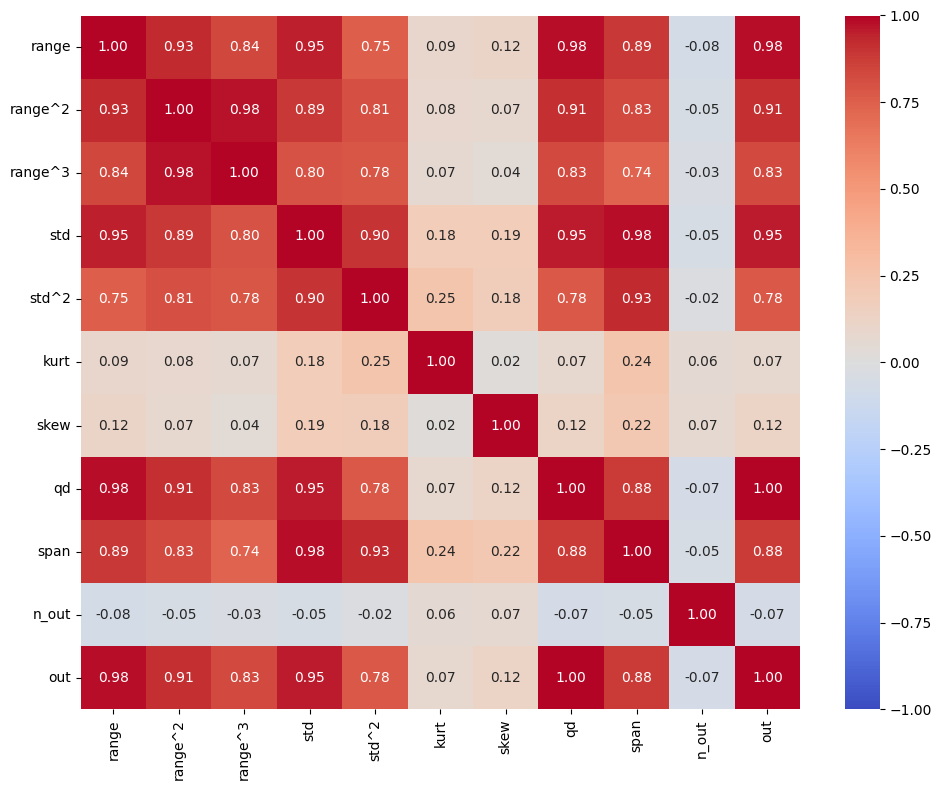

List of features to remove (correlation > 0.95): ['range^3', 'qd', 'span', 'out']


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_features = pd.read_csv('features_all.csv', sep=';')

corr_matrix = df_features.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f")
plt.tight_layout()
plt.show()

threshold = 0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_features = [column for column in upper.columns if any(upper[column].abs() > threshold)]
print(f"List of features to remove (correlation > {threshold}): {redundant_features}")

##**Feature Permutation Importance Ranking**


PI for AP1:
  range: 0.3149
  range^2: 0.2327
  std: -0.0079
  std^2: -0.0217
  kurt: -0.0222
  skew: 0.0187
  n_out: 0.0169

PI for AP2:
  range: 0.0717
  range^2: 0.0217
  std: 0.0023
  std^2: 0.0124
  kurt: -0.0183
  skew: -0.0338
  n_out: 0.0042

PI for AP3:
  range: 0.1120
  range^2: 0.0430
  std: -0.0013
  std^2: 0.0085
  kurt: -0.0149
  skew: -0.0134
  n_out: -0.0381

PI for AP4:
  range: 0.2378
  range^2: 0.1829
  std: -0.0019
  std^2: -0.0061
  kurt: -0.0012
  skew: 0.0572
  n_out: -0.0246

PI for AP5:
  range: 0.1604
  range^2: 0.1309
  std: -0.0374
  std^2: -0.0098
  kurt: 0.0049
  skew: -0.0039
  n_out: 0.0424


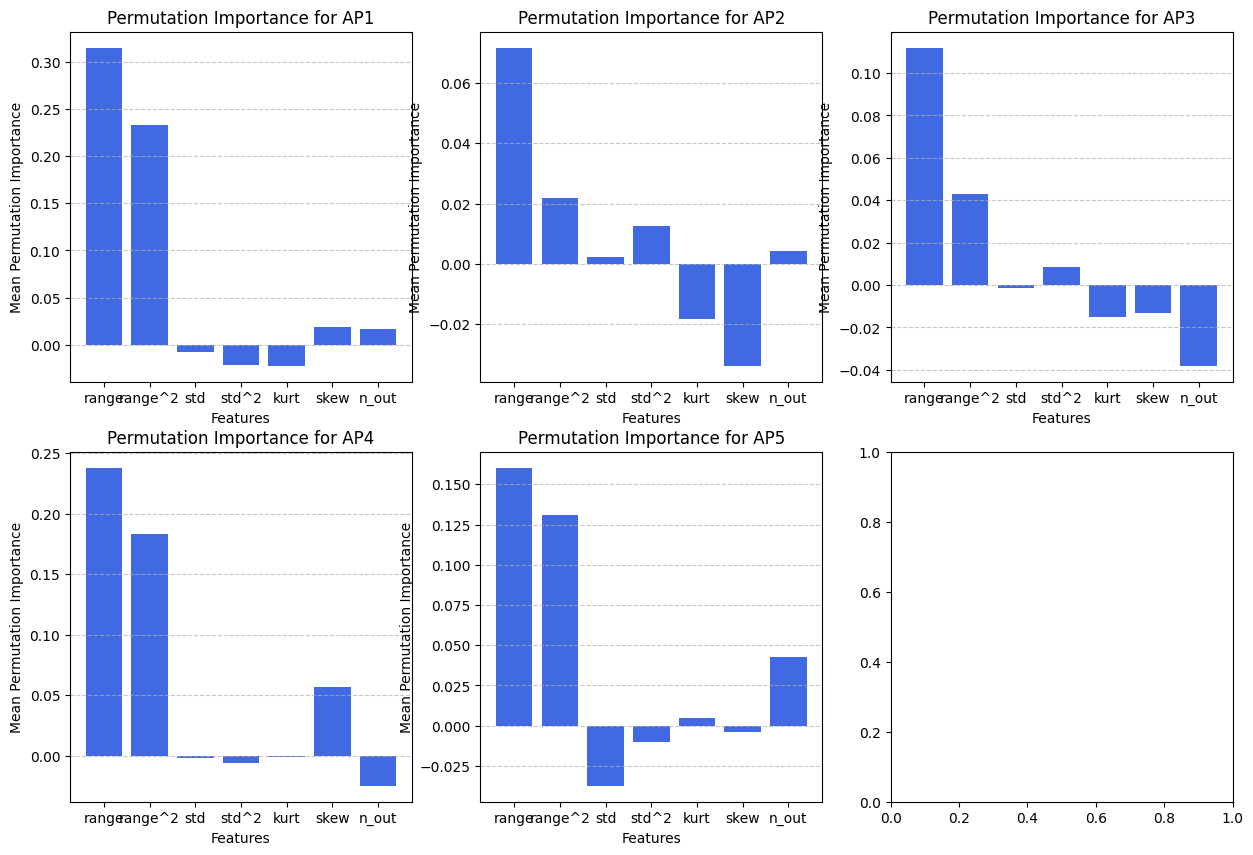

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('office_dataset_after_correlation_2.csv', sep=';')

df_train, df_test = train_test_split(df, test_size=0.2, random_state=0)

y_train = df_train[['x', 'y']]
y_test = df_test[['x', 'y']]

aps = ['ap1', 'ap2', 'ap3', 'ap4', 'ap5']
stat_types = ['range', 'range^2', 'std', 'std^2', 'kurt', 'skew', 'n_out']

ap_importances = {}

for ap in aps:
    cols = [f'{ap}_{stat}' for stat in stat_types]

    X_ap_train = df_train[cols]
    X_ap_test = df_test[cols]

    imputer = SimpleImputer(strategy='mean')
    X_ap_train_imputed = imputer.fit_transform(X_ap_train)
    X_ap_test_imputed = imputer.transform(X_ap_test)

    rf = RandomForestRegressor(n_estimators=100, random_state=60)
    rf.fit(X_ap_train_imputed, y_train)

    result = permutation_importance(rf, X_ap_test_imputed, y_test, n_repeats=30, random_state=60)

    ap_importances[ap] = result.importances_mean

    print(f"\nPI for {ap.upper()}:")
    for i, stat in enumerate(stat_types):
        print(f"  {stat}: {result.importances_mean[i]:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ap in enumerate(aps):
    axes[idx].bar(stat_types, ap_importances[ap], color='royalblue')
    axes[idx].set_title(f'Permutation Importance for {ap.upper()}')
    axes[idx].set_ylabel('Mean Permutation Importance')
    axes[idx].set_xlabel('Features')
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

plt.show()